# MC-GARCH vol feed — \(h_n,s_j,q\) → \(\sigma_p,\sigma_m\)


## Pass 1

UTC 5m bars (288/day). Daily \(h_n=\sum_j r_{n,j}^2\). Diurnal
\(\hat s_j \propto \mathrm{mean}(r^2/h)\). Intraday \(q\) via GARCH(1,1) on
\(z=r/\sqrt{h s}\).

\[\sigma_p^2\Delta t \propto q\,h\,s\cdot\Delta t,\quad
\sigma_m = \texttt{frac}\cdot\max(\mathrm{MAD}(\Delta\log p),\,10^{-4}).\]



## Empirics summary


In [1]:
from pathlib import Path
import json
OUT = Path('../../out/phase2_baselines_ssm').resolve()
s = json.loads((OUT / 'phase2_summary.json').read_text())
print('counts_total', s['counts_total'])
print('by_venue', s['counts_by_venue'])
print('overlap_nanex_ssm', s['overlap_pooled']['nanex_vs_ssm'])
print('sigma_stress', s['sigma_stress_pooled'])
print('zstar_z6', [r for r in s['zstar_pooled'] if r['z_star']==6])
print('tox', s['tox_summary'])
print('time_split', s['time_split_pooled'])
print('hour_peak_utc', s.get('hour_peak_utc'))



counts_total {'nanex': 105, 'ssm': 3668, 'vshape': 132, 'outside': 0}
by_venue {'hyperliquid': {'nanex': 70, 'ssm': 3075, 'vshape': 90, 'outside': 0, 'days': 14, 'complete_days': 14, 'trades': 1207310}, 'deribit': {'nanex': 13, 'ssm': 349, 'vshape': 16, 'outside': 0, 'days': 14, 'complete_days': 14, 'trades': 955386}, 'kraken': {'nanex': 22, 'ssm': 244, 'vshape': 26, 'outside': 0, 'days': 14, 'complete_days': 14, 'trades': 1086204}}
overlap_nanex_ssm {'n_a': 105.0, 'n_b': 3668.0, 'n_overlap': 94.0, 'jaccard': 0.025550421310138623, 'precision_a': 0.8952380952380953, 'recall_a': 0.025627044711014176}
sigma_stress [{'sigma_m_frac': 0.5, 'n_ssm': 13832}, {'sigma_m_frac': 1.0, 'n_ssm': 3668}, {'sigma_m_frac': 2.0, 'n_ssm': 808}, {'sigma_m_frac': 4.0, 'n_ssm': 177}]
zstar_z6 [{'z_star': 6.0, 'n_events': 3668, 'n_flags': 17884}]
tox {'nanex_pre_abs_imb_mean': 0.5648670054864898, 'nanex_con_abs_imb_mean': 0.7072023685575919, 'ssm_pre_abs_imb_mean': 0.614455018565678, 'ssm_con_abs_imb_mean': 0.

### Diurnal s_j vs crash intensity

`figs/fig_diurnal_vs_crashes.png`


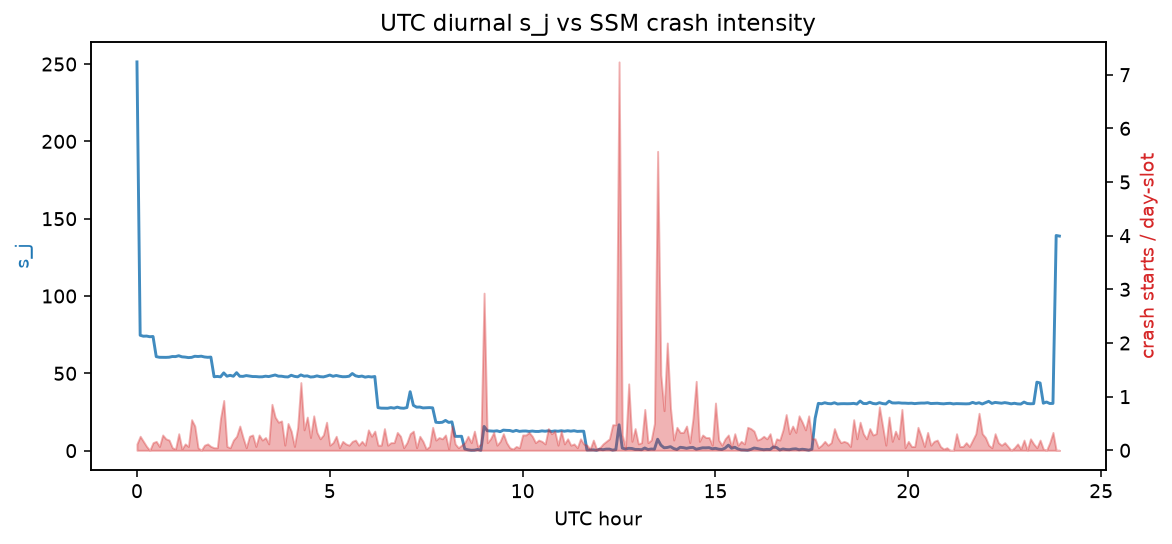

In [2]:
from IPython.display import Image, display
display(Image(filename=str(OUT / 'figs/fig_diurnal_vs_crashes.png')))



### Hourly notional (vol.curve_intraday link)

`figs/fig_hour_share.png`


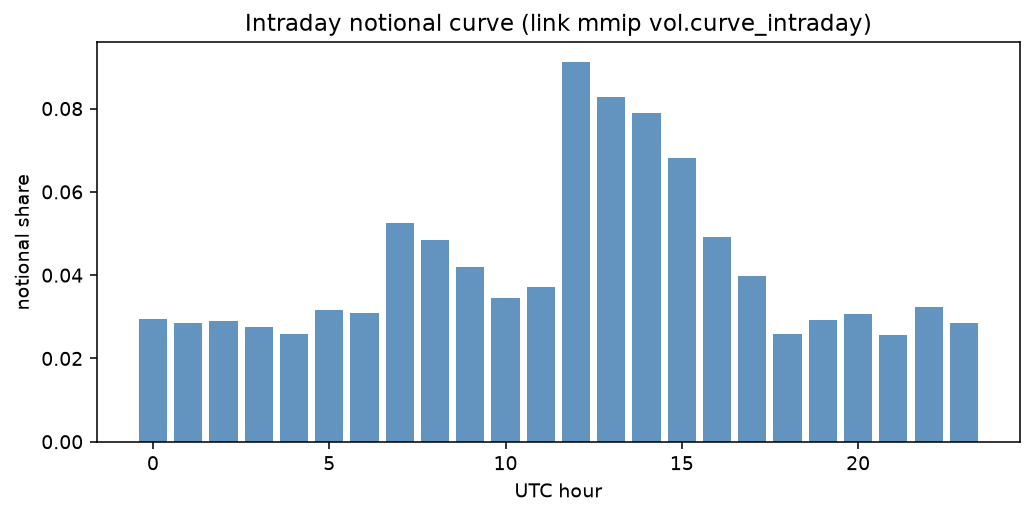

In [3]:
from IPython.display import Image, display
display(Image(filename=str(OUT / 'figs/fig_hour_share.png')))



### σ_m frac stress

`figs/fig_sigma_m_stress.png`


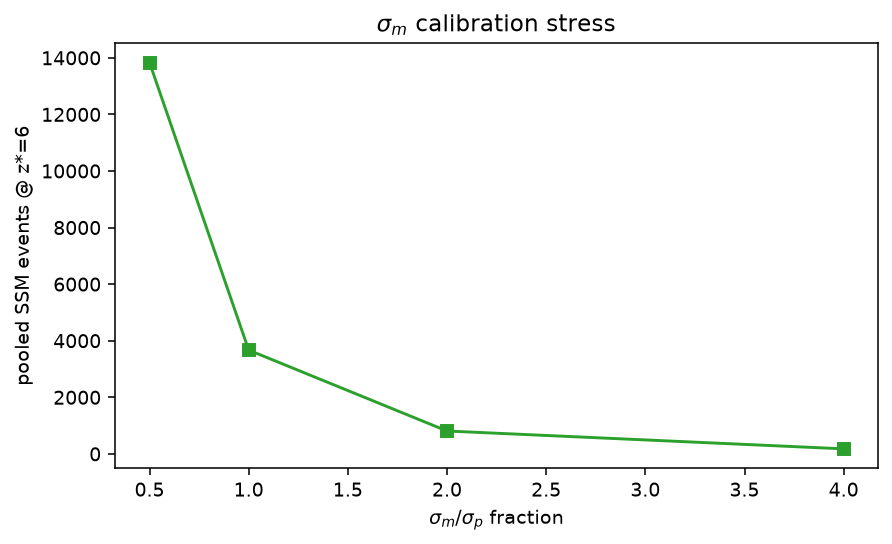

In [4]:
from IPython.display import Image, display
display(Image(filename=str(OUT / 'figs/fig_sigma_m_stress.png')))



## Pass 2

- Hourly notional peak **UTC 12** (share ≈0.09) — link mmip `vol.curve_intraday` (peak ~18 UTC on other samples; sample-dependent).
- σ_m frac stress @ z*=6: **0.5→13832**, **1→3668**, **2→808**, **4→177** events — **Kill vanity** of any single frac without floor + stress table.
- Diurnal s_j usable as **schedule prior** (Hold Promote until multi-week stable peak).



## Signal board

See `CANDIDATES.md` + `../../DESK_MEMO.md`.
